# S4 — Predicting Ad Click-Through Rate (CTR)

Starter notebook: **EDA → features → baseline → Logistic Regression → LightGBM → evaluation.**

**Before running:** download a sample of the Avazu CTR dataset and put `train.csv` in the `data/` folder.
https://www.kaggle.com/competitions/avazu-ctr-prediction/data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, log_loss, confusion_matrix, RocCurveDisplay

pd.set_option('display.max_columns', 50)
sns.set_theme()

## 1. Load the data

The full Avazu file is huge (~40M rows). We read only the first N rows so it loads fast on a laptop.

In [2]:
N_ROWS = 200_000   # increase later if your machine can handle it

df = pd.read_csv('../data/train.csv', nrows=N_ROWS)
print(df.shape)
df.head()

(200000, 24)


,id,click,hour,C1,banner_pos,site_id,site_domain,site_category,app_id,app_domain,app_category,device_id,device_ip,device_model,device_type,device_conn_type,C14,C15,C16,C17,C18,C19,C20,C21
0,1.000009e+18,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,07d7df22,a99f214a,ddd2926e,44956a24,1,2,15706,320,50,1722,0,35,-1,79
1,1.000017e+19,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,07d7df22,a99f214a,96809ac8,711ee120,1,0,15704,320,50,1722,0,35,100084,79
2,1.000037e+19,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,07d7df22,a99f214a,b3cf8def,8a4875bd,1,0,15704,320,50,1722,0,35,100084,79
3,1.000064e+19,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,07d7df22,a99f214a,e8275b8f,6332421a,1,0,15706,320,50,1722,0,35,100084,79
4,1.000068e+19,0,14102100,1005,1,fe8cc448,9166c161,0569f928,ecad2386,7801e8d9,07d7df22,a99f214a,9644d0bf,779d90c2,1,0,18993,320,50,2161,0,35,-1,157


## 2. Explore — the imbalance story

The single most important slide: **most impressions are NOT clicked.** This is why accuracy is a trap.

Overall click rate: 0.175  (17.5%)
A "never click" model would be 82.5% accurate — but useless.


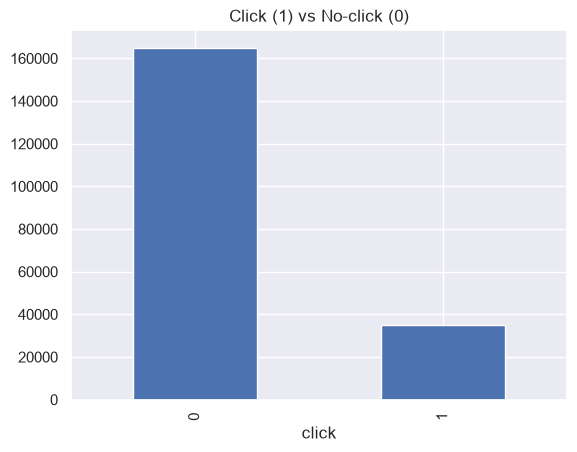

In [3]:
click_rate = df['click'].mean()
print(f'Overall click rate: {click_rate:.3f}  ({click_rate*100:.1f}%)')
print(f'A "never click" model would be {(1-click_rate)*100:.1f}% accurate — but useless.')

df['click'].value_counts().plot(kind='bar', title='Click (1) vs No-click (0)')
plt.show()

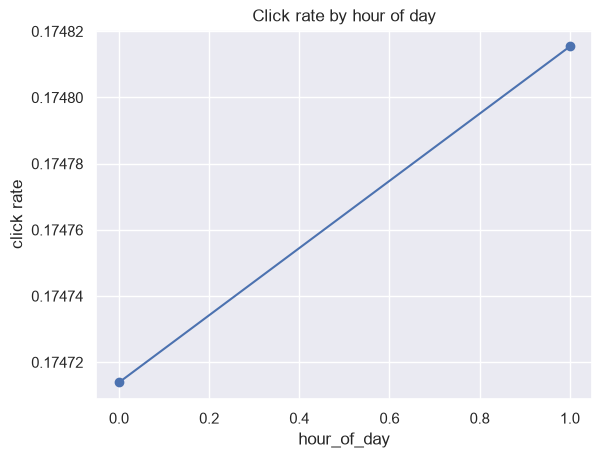

In [4]:
# Time feature: the 'hour' column is formatted YYMMDDHH. Pull out the hour of day.
df['hour_of_day'] = (df['hour'] % 100).astype(int)

ctr_by_hour = df.groupby('hour_of_day')['click'].mean()
ctr_by_hour.plot(marker='o', title='Click rate by hour of day')
plt.ylabel('click rate')
plt.show()

In [5]:
# How many unique categories does each column have? (high-cardinality columns are tricky to encode)
df.nunique().sort_values(ascending=False)

id                  200000
device_ip            76668
device_id            15040
device_model          3104
site_id               1239
site_domain           1119
app_id                 989
C14                    480
C20                    149
C17                    145
app_domain              68
C19                     39
C21                     33
site_category           20
app_category            19
C1                       6
C16                      6
banner_pos               6
C15                      5
device_type              4
device_conn_type         4
C18                      4
hour                     2
click                    2
hour_of_day              2
dtype: int64

## 3. Prepare features

We keep a small set of **low-cardinality** categorical columns for a clean first model.
(High-cardinality columns like `device_ip` need target/frequency encoding — a good "next step".)

In [6]:
cat_features = [
    'C1', 'banner_pos', 'site_category', 'app_category',
    'device_type', 'device_conn_type', 'hour_of_day',
]

X = df[cat_features].astype(str)   # treat all as categorical
y = df['click']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print('train:', X_train.shape, ' test:', X_test.shape)

train: (160000, 7)  test: (40000, 7)


## 4. Baseline

Always predict the average click rate. This is the number every real model must beat.

In [7]:
baseline_pred = np.full(len(y_test), y_train.mean())
print(f'Baseline log-loss: {log_loss(y_test, baseline_pred):.4f}')
print('Baseline AUC: 0.500 (a constant prediction cannot rank — AUC is 0.5 by definition)')

Baseline log-loss: 0.4633
Baseline AUC: 0.500 (a constant prediction cannot rank — AUC is 0.5 by definition)


## 5. Logistic Regression

One-hot encode the categories, then fit.

Note: we deliberately do **not** use `class_weight='balanced'` here. It improves AUC (ranking)
by shifting the decision threshold, but distorts the predicted probabilities and makes log-loss
*worse* than the baseline — a good example of a model that ranks better but is miscalibrated.
Leaving weights unbalanced keeps both AUC and log-loss improving together, which is the cleaner
story for a first pass. (Calibration is listed as a "next step" below.)

In [8]:
preprocess = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
])

logreg = Pipeline([
    ('prep', preprocess),
    ('clf', LogisticRegression(max_iter=1000)),
])
logreg.fit(X_train, y_train)

proba_lr = logreg.predict_proba(X_test)[:, 1]
print(f'LogReg AUC:      {roc_auc_score(y_test, proba_lr):.4f}')
print(f'LogReg log-loss: {log_loss(y_test, proba_lr):.4f}')

LogReg AUC:      0.6156
LogReg log-loss: 0.4499


## 6. LightGBM (usually the winner)

Gradient boosting handles categories natively and captures interactions between features.

In [9]:
import lightgbm as lgb

# LightGBM can use pandas 'category' dtype directly — no one-hot needed.
X_train_lgb = X_train.astype('category')
X_test_lgb = X_test.astype('category')

model = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
)
model.fit(X_train_lgb, y_train)

proba_lgb = model.predict_proba(X_test_lgb)[:, 1]
print(f'LightGBM AUC:      {roc_auc_score(y_test, proba_lgb):.4f}')
print(f'LightGBM log-loss: {log_loss(y_test, proba_lgb):.4f}')

[LightGBM] [Info] Number of positive: 27961, number of negative: 132039
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002000 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 59
[LightGBM] [Info] Number of data points in the train set: 160000, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.174756 -> initscore=-1.552287
[LightGBM] [Info] Start training from score -1.552287


LightGBM AUC:      0.6377
LightGBM log-loss: 0.4448


## 7. Evaluate & visualize (your slide material)

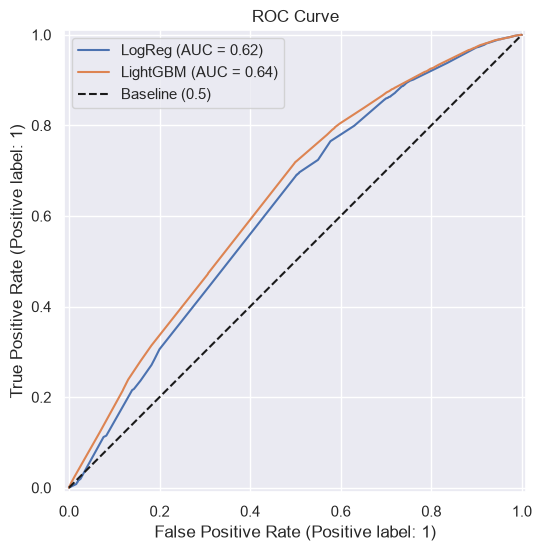

In [10]:
# ROC curves — baseline vs logistic vs boosting
fig, ax = plt.subplots(figsize=(6, 6))
RocCurveDisplay.from_predictions(y_test, proba_lr, name='LogReg', ax=ax)
RocCurveDisplay.from_predictions(y_test, proba_lgb, name='LightGBM', ax=ax)
ax.plot([0, 1], [0, 1], 'k--', label='Baseline (0.5)')
ax.set_title('ROC Curve')
ax.legend()
plt.show()

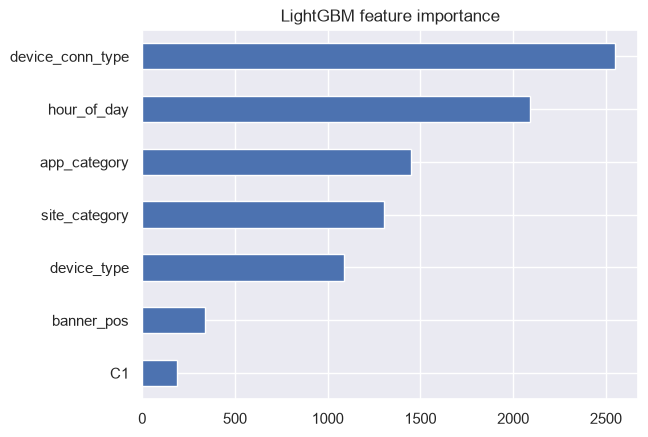

In [11]:
# Feature importance — the 'what drives clicks' slide
importances = pd.Series(model.feature_importances_, index=cat_features).sort_values()
importances.plot(kind='barh', title='LightGBM feature importance')
plt.show()

## Next steps
- Add high-cardinality features (`site_id`, `device_model`) with frequency/target encoding
- Tune LightGBM hyperparameters
- Split train/test **by time** instead of randomly (more realistic)
- Try a calibration curve to check probability quality